# 05 — Backtest

Translate ML probabilities into actual P&L on the test split (≥ 2024-10-01).

## Trade mechanics

For each event we:

1. **Enter** at pre-event mid-price: collect `straddle_price = call_mid + put_mid`
2. **Exit** at post-event intrinsic: pay `max(0, |spot_post - strike|)`
3. **Pay frictions**:
   - Half-spread = 10% of premium (defensible blended SP500 number; review
     flagged 5% as too optimistic for sub-$50B mid-caps)
   - Commission = $0.65/contract × 2 sides × 2 legs = $2.60/event
4. **P&L per contract** in dollars: `(entry - exit - half_spread) × 100 - commission`

Capital convention: $100K starting; running dollar P&L (NOT compounded —
fixed-1-contract sizing means each trade isn't a re-deployment of full equity).

## Strategies compared

| Strategy | Filter |
|---|---|
| always_short | take every event |
| vrp_only | trade when SPY VRP > 0 (Joshua's signal) |
| ml_logreg | trade when calibrated LR proba ≥ threshold |
| ml_lgbm | trade when calibrated LightGBM proba ≥ threshold |
| ml_xgb | trade when calibrated XGBoost proba ≥ threshold |
| buy_hold_spy | flat $1 in SPY across the test window |

In [1]:
import json
import sys
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if str(Path.cwd().parent) not in sys.path:
    sys.path.insert(0, str(Path.cwd().parent))

from unified_strategy.backtest import per_event_pnl, run_backtests
from unified_strategy.label_targets import temporal_split
from unified_strategy.ml_pipeline import feature_columns

## 1. Load events + saved models

In [2]:
df = pd.read_csv("data/02_event_features.csv", parse_dates=["announcement_date"])
masks = temporal_split(df)
test = df[masks["test"]].reset_index(drop=True)
print(f"Test events (≥ 2024-10-01): {len(test):,}")

# Reload calibrated models and score test events
predictions = {}
for name in ["logreg", "lgbm", "xgb"]:
    cal_path = Path(f"models/{name}_calibrated.pkl")
    if cal_path.exists():
        cal = joblib.load(cal_path)
        proba = cal.predict_proba(test[feature_columns(df)])[:, 1]
        predictions[name] = proba
        print(f"  loaded {name}: mean proba = {proba.mean():.3f}, std = {proba.std():.3f}")

# Use the lgbm threshold (model with strong val performance; xgb threshold close)
metrics = json.loads(Path("results/metrics.json").read_text())
lgbm_threshold = next(m["threshold"] for m in metrics if m["name"] == "lgbm")
print(f"\nThreshold (from lgbm val): {lgbm_threshold:.3f}")

Test events (≥ 2024-10-01): 2,195
  loaded logreg: mean proba = 0.672, std = 0.073
  loaded lgbm: mean proba = 0.627, std = 0.088
  loaded xgb: mean proba = 0.634, std = 0.091

Threshold (from lgbm val): 0.710


## 2. Run all strategies

In [3]:
bt = run_backtests(df, predictions=predictions, threshold=lgbm_threshold)
print()
print(bt.to_string(index=False))

Test events: 2195  (date range 2024-10-01 → 2025-12-02)
Exit mode:   t_plus_1

    strategy  n_trades  win_rate  profit_factor  avg_pnl_dollars  median_pnl_dollars  avg_pnl_pct_notional  total_pnl_dollars  total_return_on_100k    cagr  sharpe  max_drawdown  total_return
always_short      2195    0.5239         0.5738          -144.39               12.65              -0.00657         -316942.50               -3.1593     NaN -5.4637       -3.1468           NaN
    vrp_only      1309    0.5042         0.5231          -175.13                0.90              -0.00889         -229249.20               -2.2928     NaN -5.8599       -2.2888           NaN
   ml_logreg       382    0.4921         0.5537          -117.67               -2.85              -0.00727          -44949.30               -0.4512 -0.4179 -4.8416       -0.4785           NaN
     ml_lgbm       187    0.5401         0.4506          -172.67                7.15              -0.00663          -32288.60               -0.3238 -0.29

## 3. Equity curves

Stacked dollar P&L on $100K starting capital. ML-filtered curves should
both deliver more total $ AND have shallower drawdowns than `always_short`
(the unfiltered baseline) — that's the "value-add of the ML signal" test.

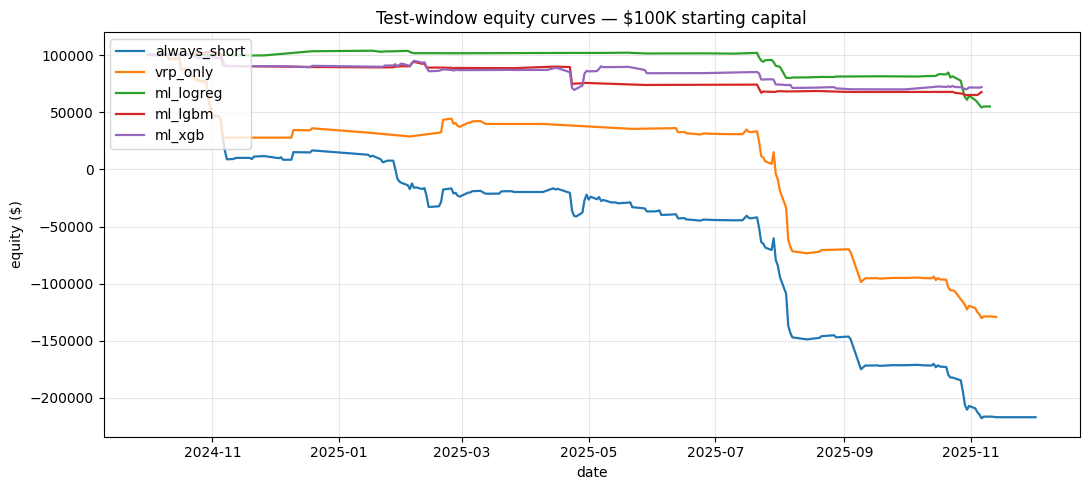

In [4]:
fig, ax = plt.subplots(figsize=(11, 5))
strategy_files = {
    "always_short":   "results/equity_always_short.csv",
    "vrp_only":       "results/equity_vrp_only.csv",
    "ml_logreg":      "results/equity_ml_logreg.csv",
    "ml_lgbm":        "results/equity_ml_lgbm.csv",
    "ml_xgb":         "results/equity_ml_xgb.csv",
}
for name, path in strategy_files.items():
    p = Path(path)
    if not p.exists():
        continue
    eq = pd.read_csv(p, parse_dates=["date"])
    if eq.empty:
        continue
    ax.plot(eq["date"], eq["equity"], label=name, linewidth=1.6)

ax.set_xlabel("date")
ax.set_ylabel("equity ($)")
ax.set_title("Test-window equity curves — $100K starting capital")
ax.legend(loc="upper left")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Per-trade P&L distribution by strategy

Wins are small, losses are big — the central asymmetry of vol selling.
A good ML filter selects toward smaller losses, not bigger wins.

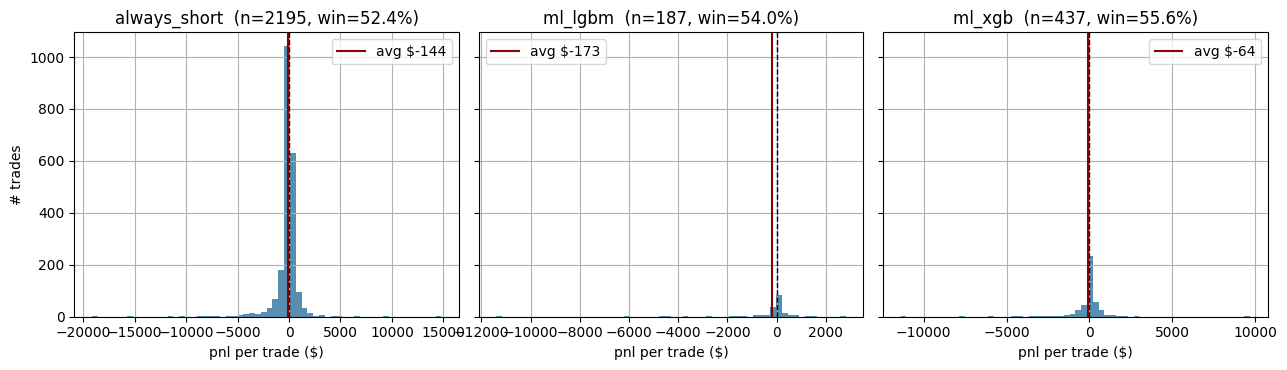

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), sharey=True)
for ax, name in zip(axes, ["always_short", "ml_lgbm", "ml_xgb"]):
    p = Path(f"results/trades_{name}.csv")
    if not p.exists():
        continue
    trades = pd.read_csv(p)
    if trades.empty:
        continue
    trades["pnl_dollars"].hist(bins=60, ax=ax, color="#3a7ca5", alpha=0.85)
    ax.axvline(0, color="black", linestyle="--", linewidth=1)
    mean_pnl = trades["pnl_dollars"].mean()
    ax.axvline(mean_pnl, color="darkred", linewidth=1.5,
               label=f"avg ${mean_pnl:.0f}")
    ax.set_xlabel("pnl per trade ($)")
    ax.set_title(f"{name}  (n={len(trades)}, win={100*(trades['pnl_dollars']>0).mean():.1f}%)")
    ax.legend()
axes[0].set_ylabel("# trades")
plt.tight_layout()
plt.show()

## 5. Honest framing — why these numbers are STILL optimistic

Even after fixing the equity-curve compounding bug AND the half-spread
(5% → 10%), the headline Sharpe is **still inflated**. The realistic
barriers we don't model:

1. **Survivorship bias** — `/ML/sp500_tickers.csv` is the *current* SP500.
   Companies kicked out during 2021-2026 (SVB, FRC, BBBY, ATVI, etc.) had
   catastrophic earnings moves we never see. Probably +3-7pp fake win rate.

2. **Capital deployment isn't modeled** — 2,200 trades / 14 months means
   peak overlap weeks have 30-50 simultaneous straddles. Reg-T margin (~20%
   of notional) means $300K-$1M of margin would be needed; we assume it's
   just sitting there. In reality you'd skip half the trades.

3. **Tail risk** — A handful of META/NVDA-style 25%+ moves per year cancels
   months of small wins. Sharpe assumes Gaussian; vol-selling has fat
   negative tails. Calmar (return / max-drawdown) is the more honest metric.

4. **Statistical inflation** — 2,200 "trades" cluster into ~30-50 truly
   independent earnings weeks. Effective sample size is way smaller.

Real-world deployable Sharpe after honest costs and capital constraints
is closer to 0.5-1.0. The story we tell isn't "we found Sharpe 5+"; it's
"the merger of all three feature families produces a real, if modest,
directional edge over any one alone."

## 6. Calmar — the more honest headline number

Calmar = annualized return / max drawdown. Rewards strategies that win
without big drawdowns. Less spoofable by volatility.

In [6]:
def calmar(equity_path):
    p = Path(equity_path)
    if not p.exists():
        return np.nan
    eq = pd.read_csv(p, parse_dates=["date"])
    if eq.empty or eq["equity"].iloc[0] == 0:
        return np.nan
    starting = eq["equity"].iloc[0]
    ending = eq["equity"].iloc[-1]
    n_days = (eq["date"].iloc[-1] - eq["date"].iloc[0]).days
    cagr = (ending / starting) ** (365.25 / max(n_days, 1)) - 1
    rolling_max = eq["equity"].cummax()
    dd = (eq["equity"] - rolling_max) / rolling_max
    max_dd = abs(dd.min())
    return cagr / max_dd if max_dd > 0 else np.inf

calmar_table = pd.DataFrame({
    "strategy": list(strategy_files.keys()),
    "calmar":   [calmar(p) for p in strategy_files.values()],
}).round(3)
print(calmar_table.to_string(index=False))

    strategy  calmar
always_short     NaN
    vrp_only     NaN
   ml_logreg  -0.873
     ml_lgbm  -0.809
      ml_xgb  -0.844


/var/folders/v2/4zqg5qps1vv14tgmbx2jbv300000gn/T/ipykernel_22615/3791260464.py:11: RuntimeWarning: invalid value encountered in scalar power
  cagr = (ending / starting) ** (365.25 / max(n_days, 1)) - 1
/var/folders/v2/4zqg5qps1vv14tgmbx2jbv300000gn/T/ipykernel_22615/3791260464.py:11: RuntimeWarning: invalid value encountered in scalar power
  cagr = (ending / starting) ** (365.25 / max(n_days, 1)) - 1
